In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data=pd.read_csv("data_cts_violent_and_sexual_crime (1).csv")
data.head(10)

,Iso3_code,Country,Region,Subregion,Indicator,Dimension,Category,Sex,Age,Year,Unit of measurement,VALUE,Source
0,AZE,Azerbaijan,Asia,Western Asia,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,155.0,CTS
1,BEL,Belgium,Europe,Western Europe,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,61959.0,CTS
2,BGR,Bulgaria,Europe,Eastern Europe,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,3806.0,CTS
3,BHR,Bahrain,Asia,Western Asia,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,2701.0,CTS
4,BLR,Belarus,Europe,Eastern Europe,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,4032.0,CTS
5,BMU,Bermuda,Americas,Northern America,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,522.0,CTS
6,BRN,Brunei Darussalam,Asia,South-eastern Asia,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,470.0,CTS
7,CAN,Canada,Americas,Northern America,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,48135.0,CTS
8,CHE,Switzerland,Europe,Western Europe,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,6732.0,CTS
9,CMR,Cameroon,Africa,Sub-Saharan Africa,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,2998.0,CTS/NSO


In [3]:
dataPulito=data[data["VALUE"]!=0]

In [4]:
data["Indicator"].unique()

array(['Violent offences', 'Victims of serious assault',
       'Victims of sexual violence'], dtype=object)

In [5]:
violenze=data[data["Indicator"]=='Violent offences'][["Region","Unit of measurement","VALUE"]].groupby(["Region","Unit of measurement"]).sum("VALUE")
violenze

VALUE
Region   Unit of measurement                      
Africa   Counts                       7.191780e+06
         Rate per 100,000 population  4.980145e+04
Americas Counts                       8.293793e+07
         Rate per 100,000 population  2.818899e+05
Asia     Counts                       1.630745e+07
         Rate per 100,000 population  5.339391e+04
Europe   Counts                       5.149472e+07
         Rate per 100,000 population  2.443704e+05
Oceania  Counts                       2.334724e+06
         Rate per 100,000 population  2.239873e+04

In [6]:
data["Unit of measurement"].unique()

array(['Counts', 'Rate per 100,000 population'], dtype=object)

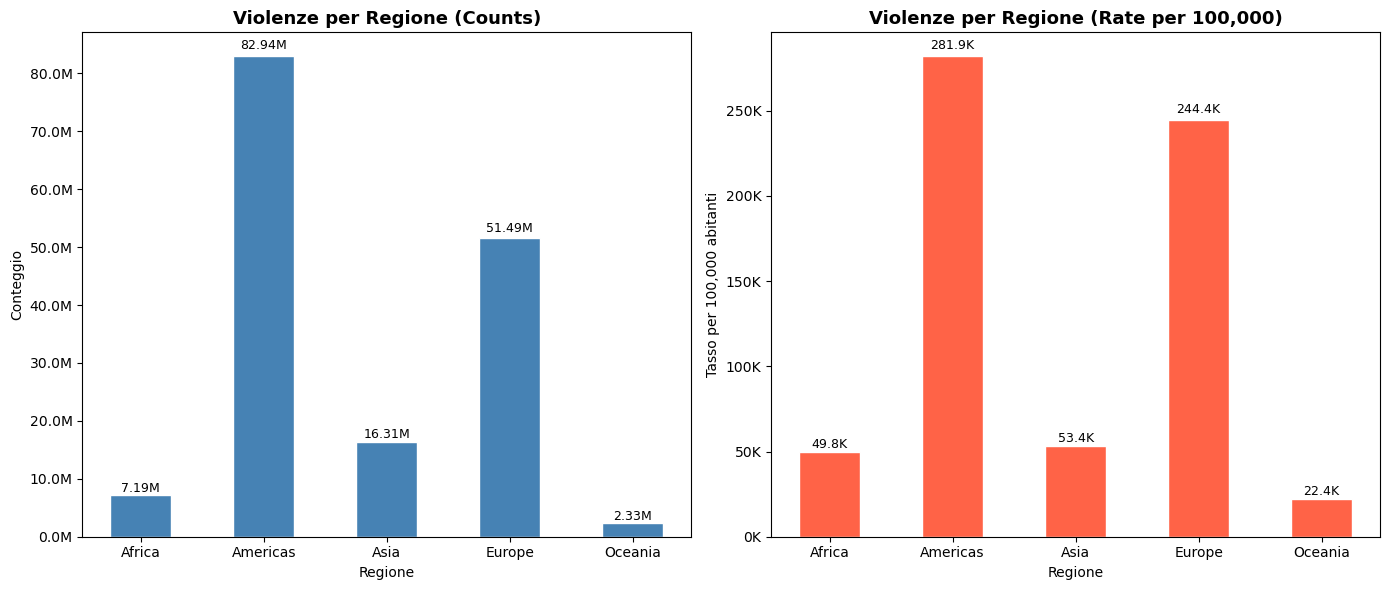

In [7]:
# Estrarre i dati dal DataFrame
counts = violenze.xs("Counts", level="Unit of measurement")["VALUE"]
rates = violenze.xs("Rate per 100,000 population", level="Unit of measurement")["VALUE"]

regioni = counts.index.tolist()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Grafico 1: Counts ---
bars1 = ax1.bar(regioni, counts, color="steelblue", edgecolor="white", width=0.5)
ax1.set_title("Violenze per Regione (Counts)", fontsize=13, fontweight="bold")
ax1.set_xlabel("Regione")
ax1.set_ylabel("Conteggio")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
             f"{bar.get_height()/1e6:.2f}M", ha="center", va="bottom", fontsize=9)

# --- Grafico 2: Rate per 100,000 ---
bars2 = ax2.bar(regioni, rates, color="tomato", edgecolor="white", width=0.5)
ax2.set_title("Violenze per Regione (Rate per 100,000)", fontsize=13, fontweight="bold")
ax2.set_xlabel("Regione")
ax2.set_ylabel("Tasso per 100,000 abitanti")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
             f"{bar.get_height()/1e3:.1f}K", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("violenze_per_regione.png", dpi=150)
plt.show()

In [8]:
data[data["Region"]=="Asia"].groupby("Region").min() #è stato un anno tabù -> questo fa pensare non che non siano avvenute violenze ma che semplicemente non ci sono state denunce fatte

,Iso3_code,Country,Subregion,Indicator,Dimension,Category,Sex,Age,Year,Unit of measurement,VALUE,Source
Region,,,,,,,,,,,,
Asia,ARE,Armenia,Central Asia,Victims of serious assault,by relationship to perpetrator,Acts intended to induce fear or emotional dist...,Female,Total,2003,Counts,0.0,CTS


In [9]:
data[data["Region"]=="Asia"].groupby("Region").max()

,Iso3_code,Country,Subregion,Indicator,Dimension,Category,Sex,Age,Year,Unit of measurement,VALUE,Source
Region,,,,,,,,,,,,
Asia,YEM,Yemen,Western Asia,Violent offences,by type of offence,Sexual violence: Sexual assault,Total,Total,2024,"Rate per 100,000 population",334669.0,MoI/CTS


In [10]:
data[
    (data["Region"] == "Europe") &
    ((data["Country"] == "Ukraine") | (data["Country"] == "Russian Federation"))
].groupby("Year").sum("VALUE")

,VALUE
Year,
2003,45716.425896
2004,385016.974606
2005,488356.511146
2006,491384.843298
2007,411834.673185
2008,360531.394502
2009,308185.486874
2010,249719.501979
2011,184010.657744


In [11]:
def grafico(ax,continente):
    valori=dataPulito[dataPulito["Region"]==continente].groupby("Year").sum("VALUE")
    anni=dataPulito[dataPulito["Region"]==continente]["Year"].unique()
    ax.plot(anni,valori,marker='o')

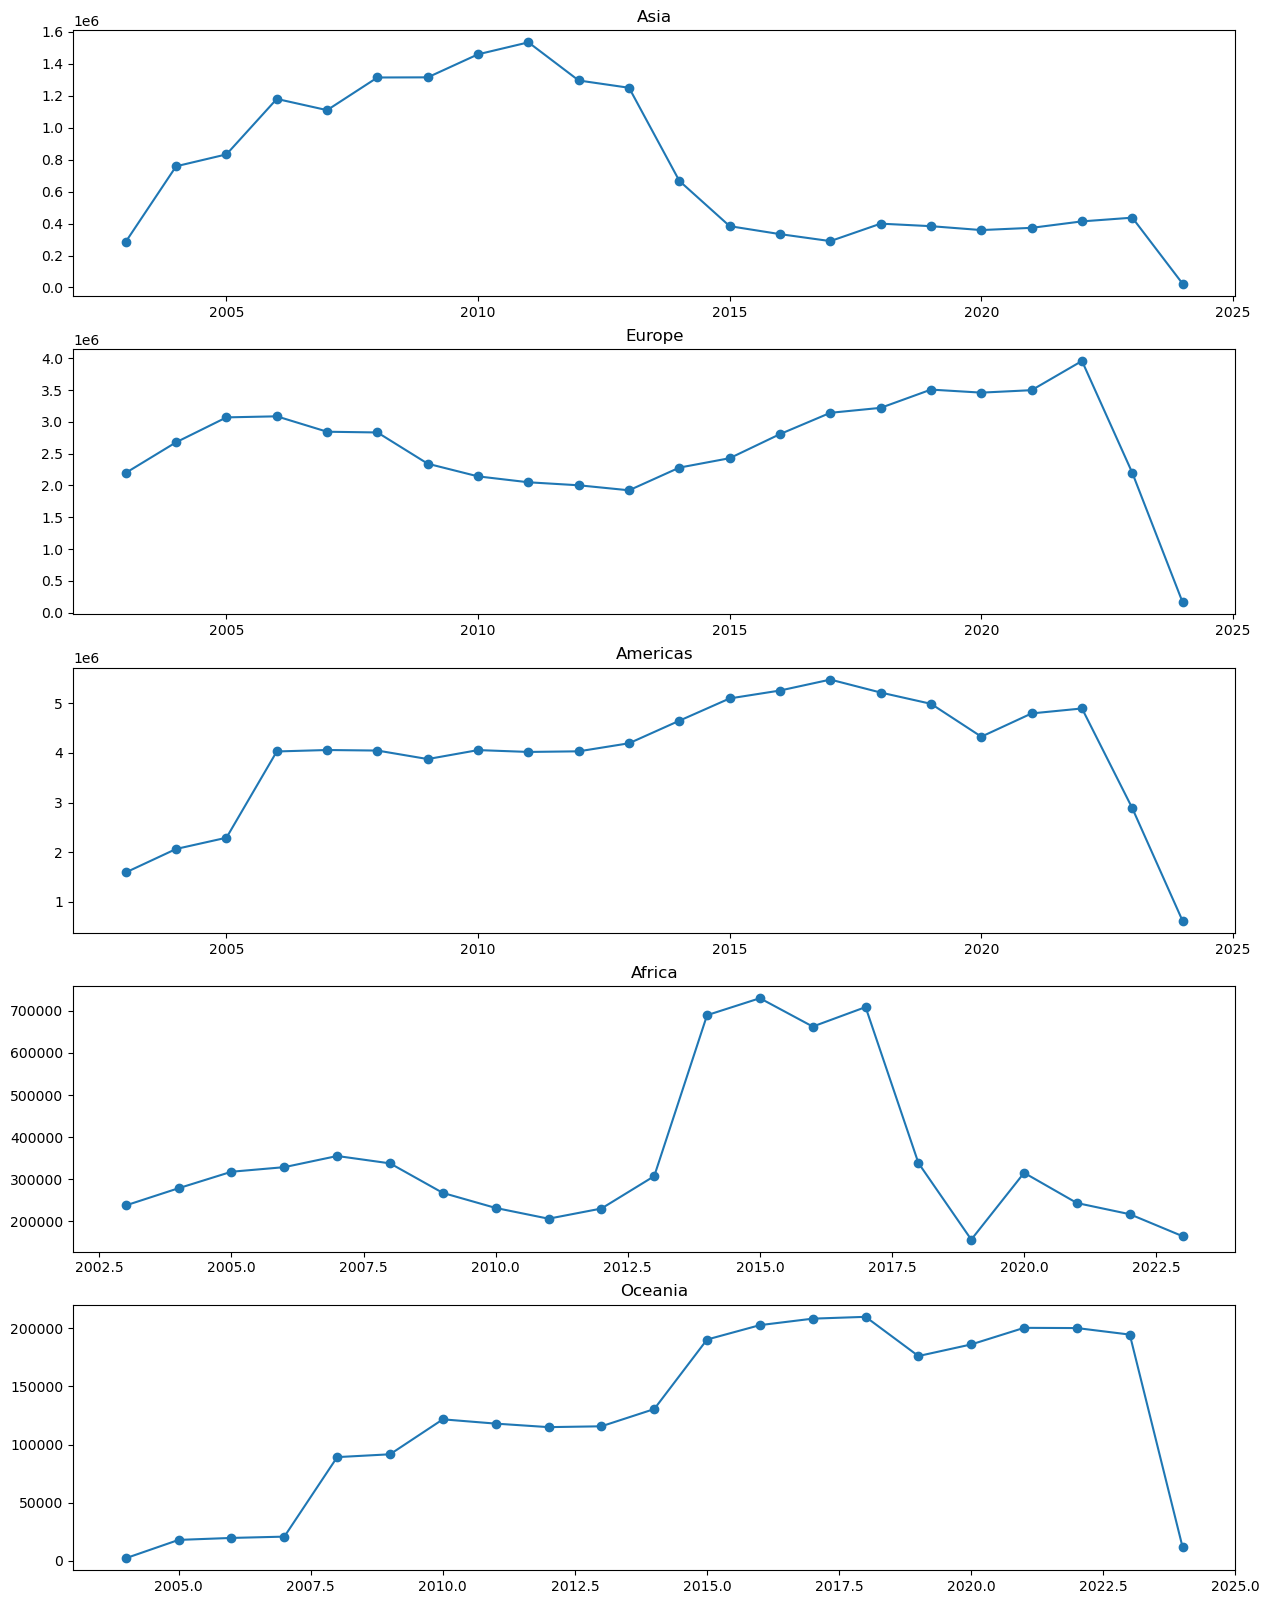

In [12]:
continenti=data["Region"].unique()
fig, axs= plt.subplots(nrows=5, figsize=(15,20))

for i,c in enumerate(continenti):
    grafico(axs[i],c)
    axs[i].set_title(c)

plt.show()

In [13]:
data["Sex"].unique()

array(['Total', 'Male', 'Female'], dtype=object)

In [14]:
data["Dimension"].unique()

array(['by type of offence', 'by relationship to perpetrator'],
      dtype=object)

In [15]:
data[data["Country"]=="Ukraine"]

,Iso3_code,Country,Region,Subregion,Indicator,Dimension,Category,Sex,Age,Year,Unit of measurement,VALUE,Source
50,UKR,Ukraine,Europe,Eastern Europe,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,5703.000000,CTS/DMDB
119,UKR,Ukraine,Europe,Eastern Europe,Violent offences,by type of offence,Serious assault,Total,Total,2004,Counts,5538.000000,CTS/DMDB
207,UKR,Ukraine,Europe,Eastern Europe,Violent offences,by type of offence,Serious assault,Total,Total,2005,Counts,6707.000000,CTS/DMDB
306,UKR,Ukraine,Europe,Eastern Europe,Violent offences,by type of offence,Serious assault,Total,Total,2006,Counts,6464.000000,CTS/DMDB
400,UKR,Ukraine,Europe,Eastern Europe,Violent offences,by type of offence,Serious assault,Total,Total,2007,Counts,5716.000000,CTS/DMDB
...,...,...,...,...,...,...,...,...,...,...,...,...,...
30218,UKR,Ukraine,Europe,Eastern Europe,Violent offences,by type of offence,Robbery,Total,Total,2007,"Rate per 100,000 population",68.559460,CTS
30318,UKR,Ukraine,Europe,Eastern Europe,Violent offences,by type of offence,Robbery,Total,Total,2008,"Rate per 100,000 population",78.871530,CTS
30418,UKR,Ukraine,Europe,Eastern Europe,Violent offences,by type of offence,Robbery,Total,Total,2009,"Rate per 100,000 population",59.193032,CTS
30521,UKR,Ukraine,Europe,Eastern Europe,Violent offences,by type of offence,Robbery,Total,Total,2010,"Rate per 100,000 population",50.154983,CTS


## Cosa fare
- analizzare le diverse violenze [quindi le category] per 'by type of offence' ALESSIA
- analizzare le diverse violenze [quindi le category] per 'by relationship to perpetrator' REBECCA
- analizzare nei periodi di guerra continente o stati KIRTI

### Analizzare le diverse violenze [quindi le category] per 'by relationship to perpetrator' REBECCA

In [16]:
relationship = data[data['Dimension'] == "by relationship to perpetrator"]
relationship = relationship[relationship["Unit of measurement"] == "Counts"]

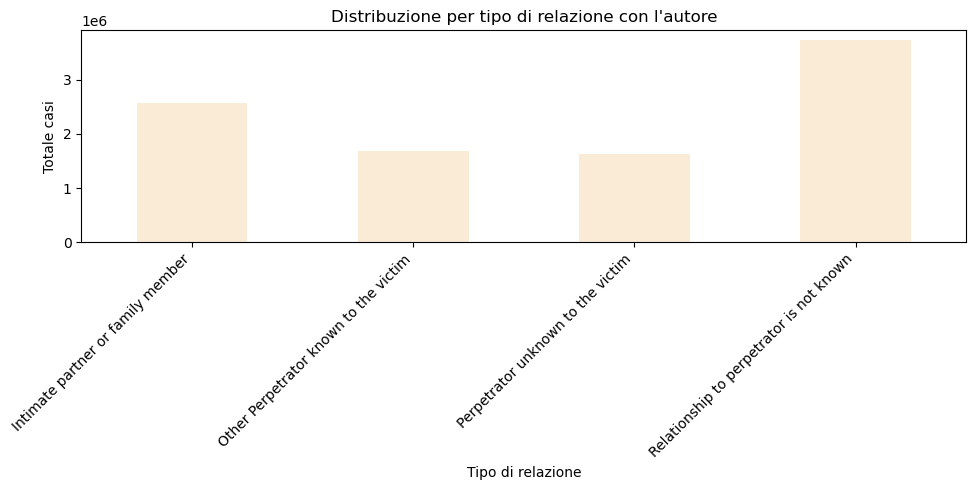

In [17]:
import matplotlib.pyplot as plt

# filtro dimensione corretta
relationship = data[data['Dimension'] == "by relationship to perpetrator"].copy()

# filtro solo conteggi reali
relationship = relationship[relationship["Unit of measurement"] == "Counts"]

# aggrego correttamente (SOMMO i valori veri)
relationshipPerCategoria = relationship.groupby("Category")["VALUE"].sum()

# grafico
fig, ax = plt.subplots(figsize=(10,5))

relationshipPerCategoria.plot(
    kind="bar",
    ax=ax,
    color="antiquewhite"
)

# titoli
ax.set_title("Distribuzione per tipo di relazione con l'autore")
ax.set_xlabel("Tipo di relazione")
ax.set_ylabel("Totale casi")

# etichette leggibili
plt.xticks(rotation=45, ha="right")

plt.tight_layout()

# salva prima dello show
fig.savefig("relazioni_categorie.png", dpi=300, bbox_inches="tight")

plt.show()

In [18]:
relationshipPerRegione = relationship["Region"].value_counts()
relationshipPerRegione

Region
Europe      1748
Americas    1153
Asia         249
Oceania       82
Africa        32
Name: count, dtype: int64

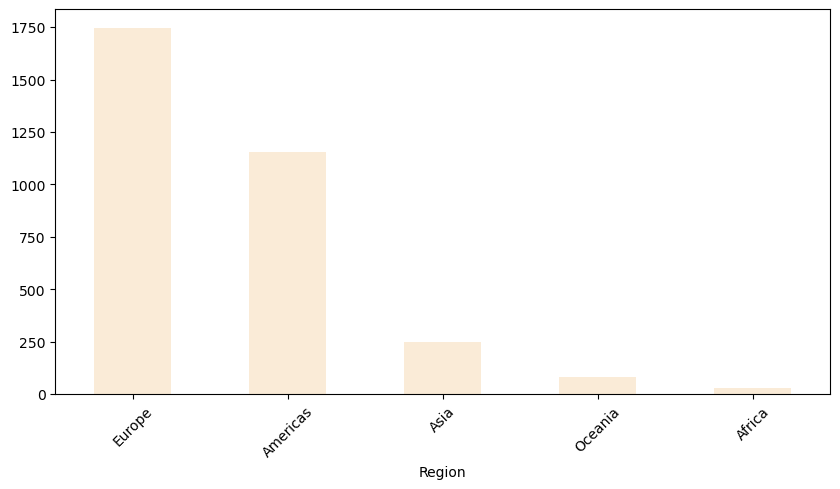

In [19]:
fig, ax = plt.subplots(figsize=(10,5))
relationshipPerRegione.plot(kind="bar", ax=ax, color="antiquewhite")
plt.xticks(rotation=45)
plt.show()

In [20]:
relationship["Category"].unique()

array(['Intimate partner or family member',
       'Other Perpetrator known to the victim',
       'Perpetrator unknown to the victim',
       'Relationship to perpetrator is not known'], dtype=object)

#### Fidanzato o membro della famiglia

In [21]:
intimi = relationship[relationship["Category"] == 'Intimate partner or family member']
#intimi
#1858 righe

In [22]:
intimiPerPaese = intimi["Country"].value_counts()
intimiPerPaese

Country
Austria                                       40
Germany                                       40
Slovenia                                      40
Slovakia                                      40
Finland                                       40
Canada                                        40
Switzerland                                   40
Colombia                                      38
Lithuania                                     32
Romania                                       32
Czechia                                       28
Latvia                                        28
France                                        28
Bolivia (Plurinational State of)              28
Spain                                         28
Croatia                                       24
Mexico                                        24
Saint Kitts and Nevis                         24
Guatemala                                     24
El Salvador                                   24
Myanmar     

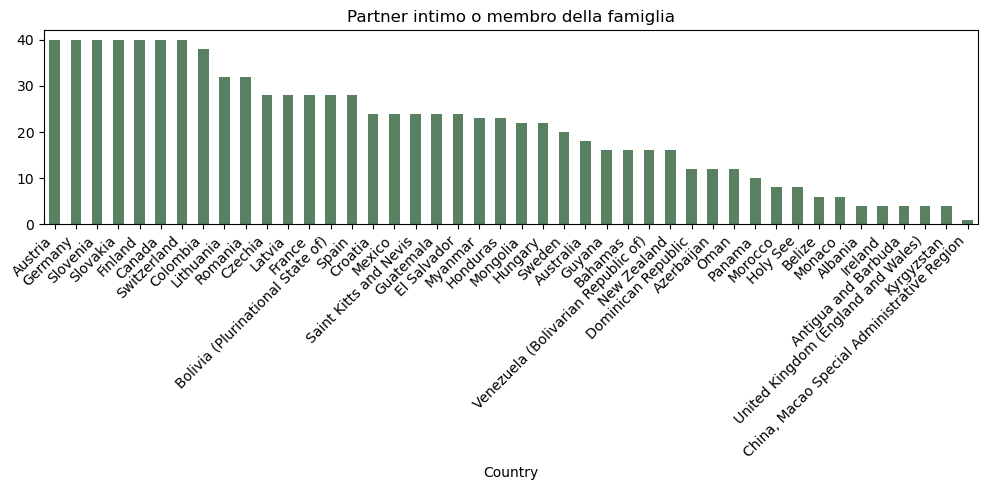

In [23]:
fig, ax = plt.subplots(figsize=(10,5))
intimiPerPaese.plot(kind="bar", ax=ax, color="#588061")
ax.set_title("Partner intimo o membro della famiglia")

plt.xticks(rotation=45, ha="right")  # ruota e allinea meglio
plt.tight_layout()                   # sistema gli spazi interni

fig.savefig("relazioneIntimo.png", transparent=True, bbox_inches="tight")
plt.show()

### Conoscente

In [24]:
conoscenti = relationship[relationship["Category"] == 'Other Perpetrator known to the victim']
#conoscenti
#1460 righe

In [25]:
conoscentiPerPaese = conoscenti["Country"].value_counts()
conoscentiPerPaese

Country
Austria                               40
Switzerland                           40
Canada                                40
Colombia                              38
Germany                               36
Lithuania                             32
Bolivia (Plurinational State of)      28
Spain                                 28
Latvia                                28
Czechia                               28
Myanmar                               25
Mexico                                24
El Salvador                           24
Guyana                                24
Croatia                               24
Saint Kitts and Nevis                 24
Honduras                              23
Mongolia                              22
Sweden                                20
New Zealand                           16
Slovakia                              16
Venezuela (Bolivarian Republic of)    16
Bahamas                               16
Slovenia                              16
Hungary 

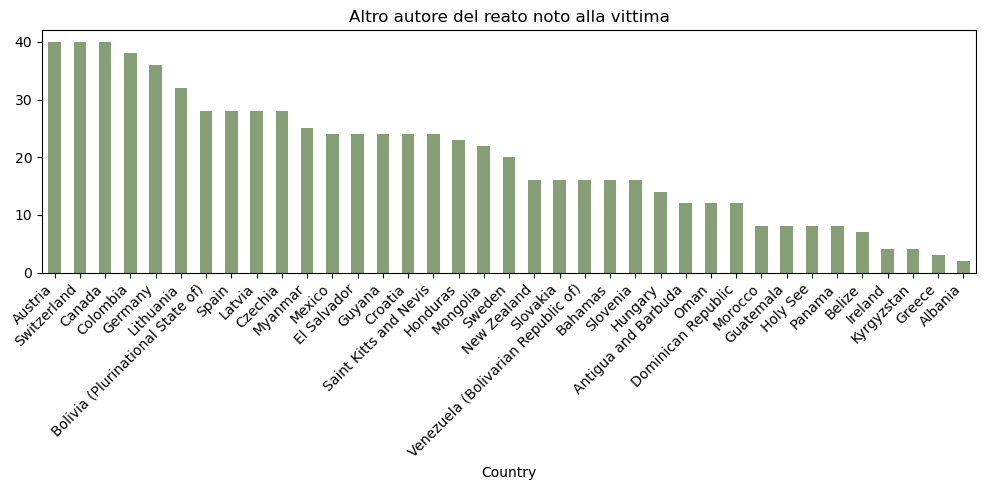

In [26]:
fig, ax = plt.subplots(figsize=(10,5))
conoscentiPerPaese.plot(kind="bar", ax=ax, color="#869F77")

ax.set_title("Altro autore del reato noto alla vittima")

plt.xticks(rotation=45, ha="right")  # ruota e allinea meglio
plt.tight_layout()                   # sistema gli spazi interni

plt.show()
fig.savefig(f"relazioneConoscente", transparent=True, bbox_inches="tight")

### Sconosciuto

In [27]:
sconosciuti = relationship[relationship["Category"] == 'Perpetrator unknown to the victim']
#sconosciuti
#1478 righe

In [28]:
sconosciutiPerPaese = sconosciuti["Country"].value_counts()
sconosciutiPerPaese

Country
Austria                               40
Switzerland                           40
Canada                                40
Slovenia                              40
Colombia                              38
Germany                               36
Lithuania                             32
Slovakia                              32
Spain                                 28
Latvia                                28
Czechia                               28
Sweden                                28
Myanmar                               25
Mexico                                24
El Salvador                           24
Saint Kitts and Nevis                 24
Croatia                               24
Mongolia                              22
Bolivia (Plurinational State of)      20
New Zealand                           16
Honduras                              16
Venezuela (Bolivarian Republic of)    16
Bahamas                               16
Guyana                                16
Hungary 

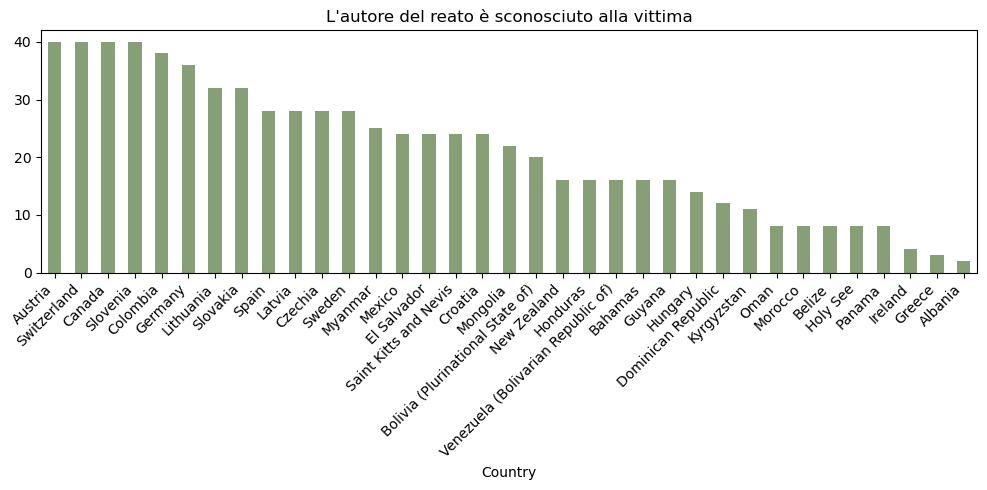

In [29]:
fig, ax = plt.subplots(figsize=(10,5))
sconosciutiPerPaese.plot(kind="bar", ax=ax, color="#869F77")

ax.set_title("L'autore del reato è sconosciuto alla vittima")

plt.xticks(rotation=45, ha="right")  # ruota e allinea meglio
plt.tight_layout()                   # sistema gli spazi interni


fig.savefig("relazioneSconosciuta.png", transparent=True, bbox_inches="tight")
plt.show()

### Ignoto

In [30]:
ignoti = relationship[relationship["Category"] == 'Relationship to perpetrator is not known']
#ignoti
#1732 righe

In [31]:
ignotiPerPaese = ignoti["Country"].value_counts()
ignotiPerPaese

Country
Austria                               40
Switzerland                           40
Finland                               40
Sweden                                40
Canada                                40
Colombia                              36
Germany                               36
Italy                                 32
Lithuania                             32
Norway                                32
Spain                                 28
Czechia                               28
Bolivia (Plurinational State of)      28
Poland                                28
France                                26
Saint Kitts and Nevis                 24
Croatia                               24
Mexico                                22
Guyana                                22
Latvia                                20
Honduras                              20
Azerbaijan                            20
Mongolia                              18
Guatemala                             18
Venezuel

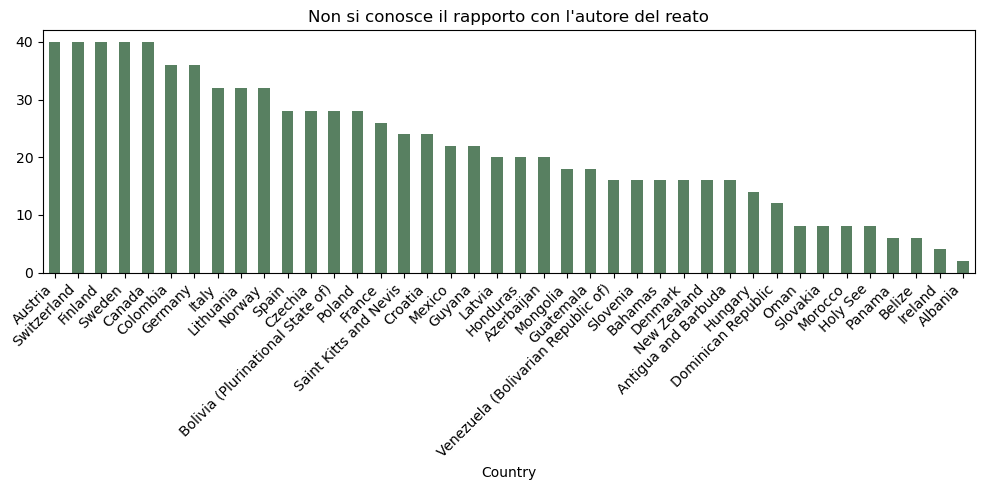

In [32]:
fig, ax = plt.subplots(figsize=(10,5))
ignotiPerPaese.plot(kind="bar", ax=ax, color="#588061")

ax.set_title("Non si conosce il rapporto con l'autore del reato")

plt.xticks(rotation=45, ha="right")  # ruota e allinea meglio
plt.tight_layout()                   # sistema gli spazi interni

plt.show()
fig.savefig(f"relazioneIgnota", transparent=True, bbox_inches="tight")

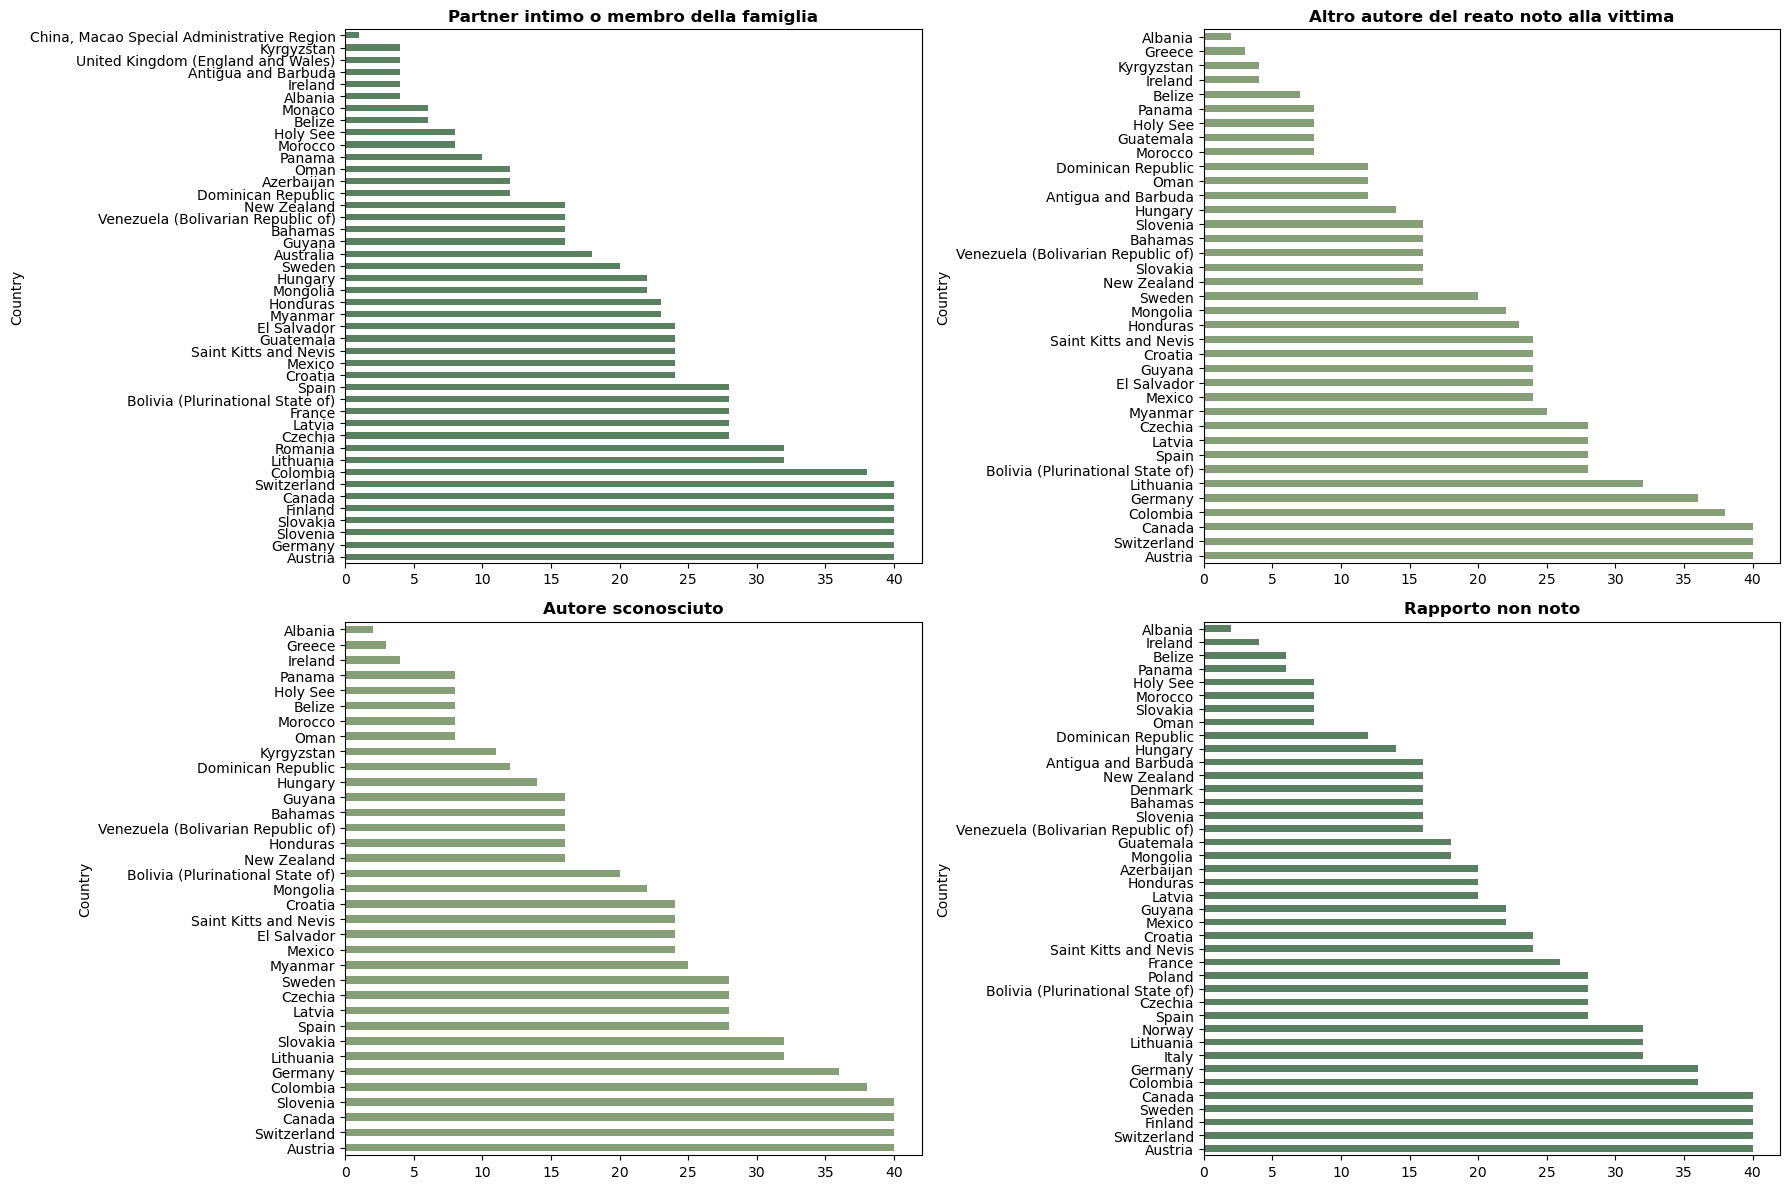

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(18,12))

intimiPerPaese.plot(kind="barh", ax=axes[0,0], color="#588061")
axes[0,0].set_title("Partner intimo o membro della famiglia", fontweight='bold')

conoscentiPerPaese.plot(kind="barh", ax=axes[0,1], color="#869F77")
axes[0,1].set_title("Altro autore del reato noto alla vittima", fontweight='bold')

sconosciutiPerPaese.plot(kind="barh", ax=axes[1,0], color="#869F77")
axes[1,0].set_title("Autore sconosciuto", fontweight='bold')

ignotiPerPaese.plot(kind="barh", ax=axes[1,1], color="#588061")
axes[1,1].set_title("Rapporto non noto", fontweight='bold')

plt.tight_layout()

fig.savefig("tutti_grafici.png", transparent=True, bbox_inches="tight")
plt.show()

In [34]:
data.head(1)

,Iso3_code,Country,Region,Subregion,Indicator,Dimension,Category,Sex,Age,Year,Unit of measurement,VALUE,Source
0,AZE,Azerbaijan,Asia,Western Asia,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,155.0,CTS


### Grafico temporale generale

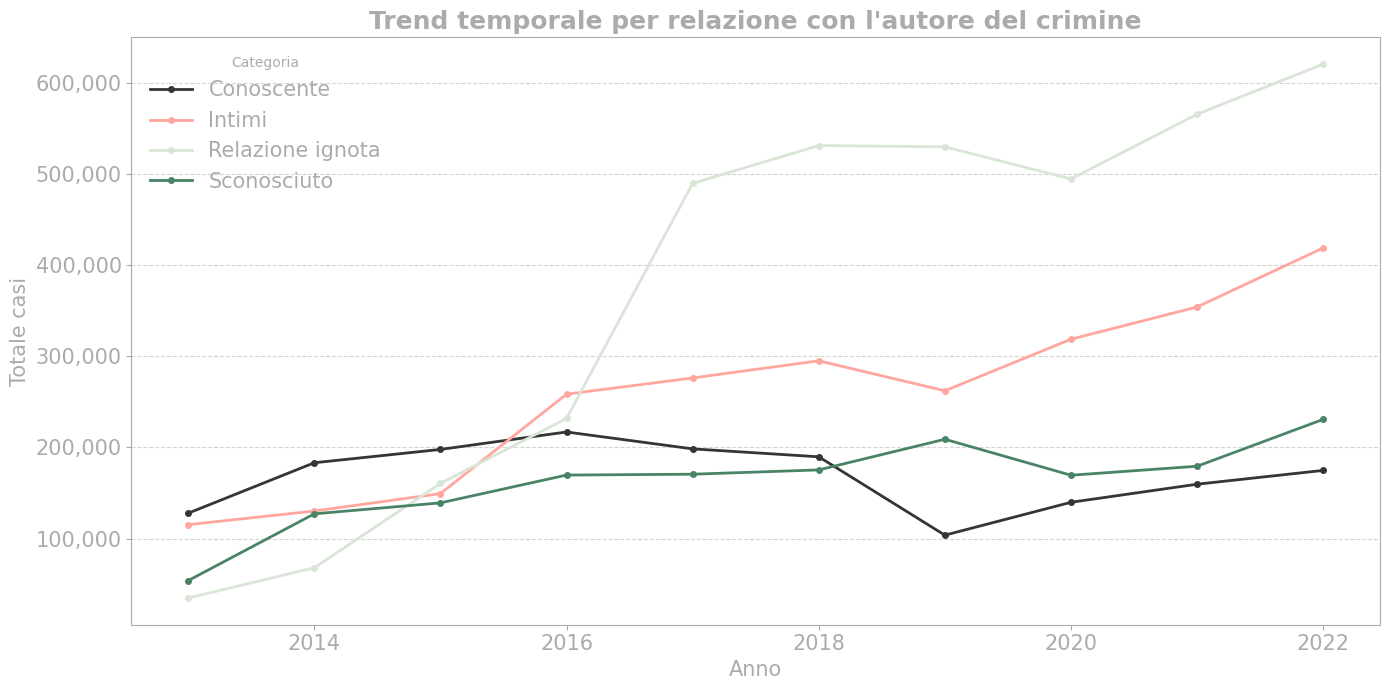

In [39]:
import matplotlib.pyplot as plt

# filtro dimensione
relationship = data[data['Dimension'] == "by relationship to perpetrator"].copy()

# rinomino categorie
mappa_categorie = {
    'Intimate partner or family member': 'Intimi',
    'Other Perpetrator known to the victim': 'Conoscente',
    'Perpetrator unknown to the victim': 'Sconosciuto',
    'Relationship to perpetrator is not known': 'Relazione ignota'
}

relationship["Category"] = relationship["Category"].map(mappa_categorie)

# filtro solo i conteggi
rel_filtrato = relationship[relationship["Unit of measurement"] == "Counts"]

# aggrego per anno e categoria
trend = rel_filtrato.groupby(["Year", "Category"])["VALUE"].sum().reset_index()

# colori linee
coloreReati = {
    "Intimi": "#FFA69E",
    "Conoscente": "#353535",
    "Sconosciuto": "#498467",
    "Relazione ignota": "#D9E5D6"
}

colore_testo = "#ababab"

# grafico
fig, ax = plt.subplots(figsize=(14, 7))

for cat in trend["Category"].unique():
    dati = trend[trend["Category"] == cat]
    ax.plot(
        dati["Year"],
        dati["VALUE"],
        marker="o",
        linewidth=2,
        markersize=4,
        label=cat,
        color=coloreReati[cat]
    )

# titoli e label
ax.set_title("Trend temporale per relazione con l'autore del crimine", color=colore_testo, fontsize=18, fontweight='bold')
ax.set_xlabel("Anno", color=colore_testo, fontsize=15)
ax.set_ylabel("Totale casi", color=colore_testo, fontsize=15)

# formato numeri asse y
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# tick
ax.tick_params(axis='x', colors=colore_testo)
ax.tick_params(axis='y', colors=colore_testo)

# bordi (spines)
for spine in ax.spines.values():
    spine.set_edgecolor(colore_testo)

# legenda
legend = ax.legend(title="Categoria", loc="upper left", fontsize=15, framealpha=0)
plt.setp(legend.get_texts(), color=colore_testo)
legend.get_title().set_color(colore_testo)

# griglia
ax.grid(axis="y", linestyle="--", alpha=0.5, color=colore_testo)

plt.yticks(fontsize=15)
plt.xticks(fontsize=15)

# layout
plt.tight_layout()

fig.savefig("grafico_temporale.png", dpi=300, transparent=True)

plt.show()

### Grafici temporali per ogni continente

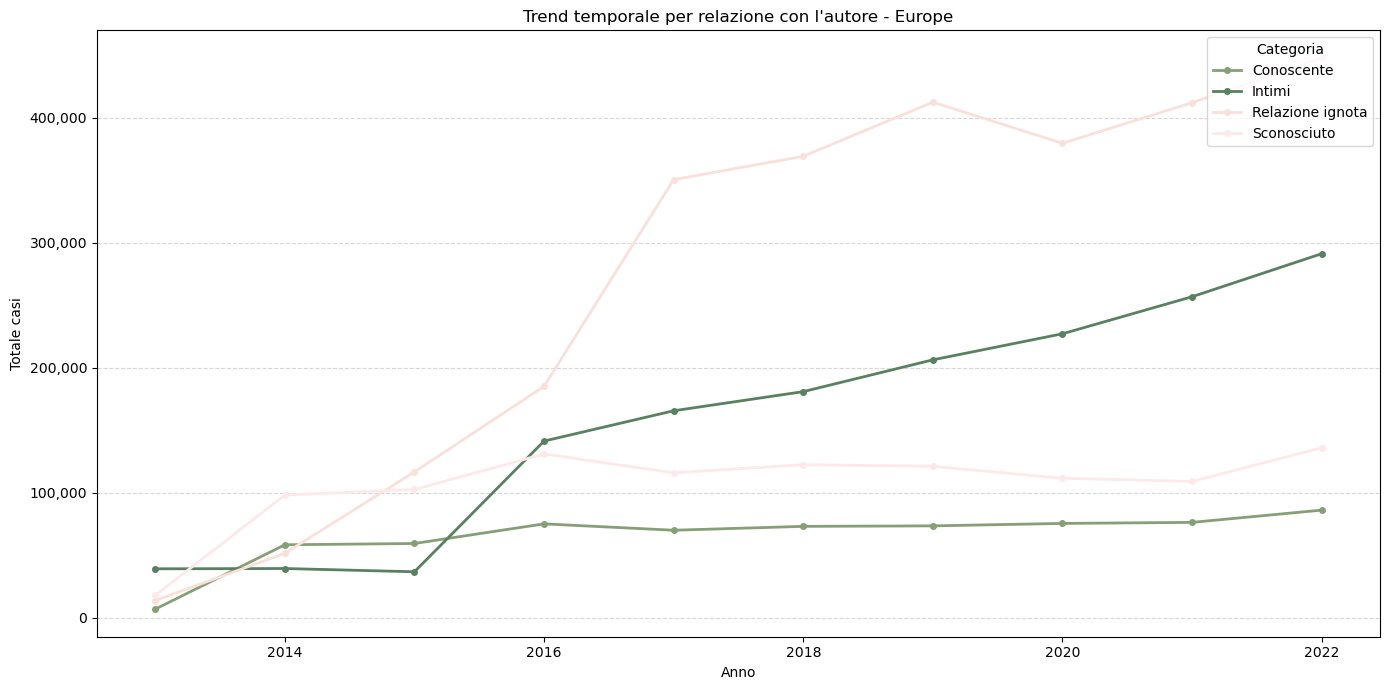

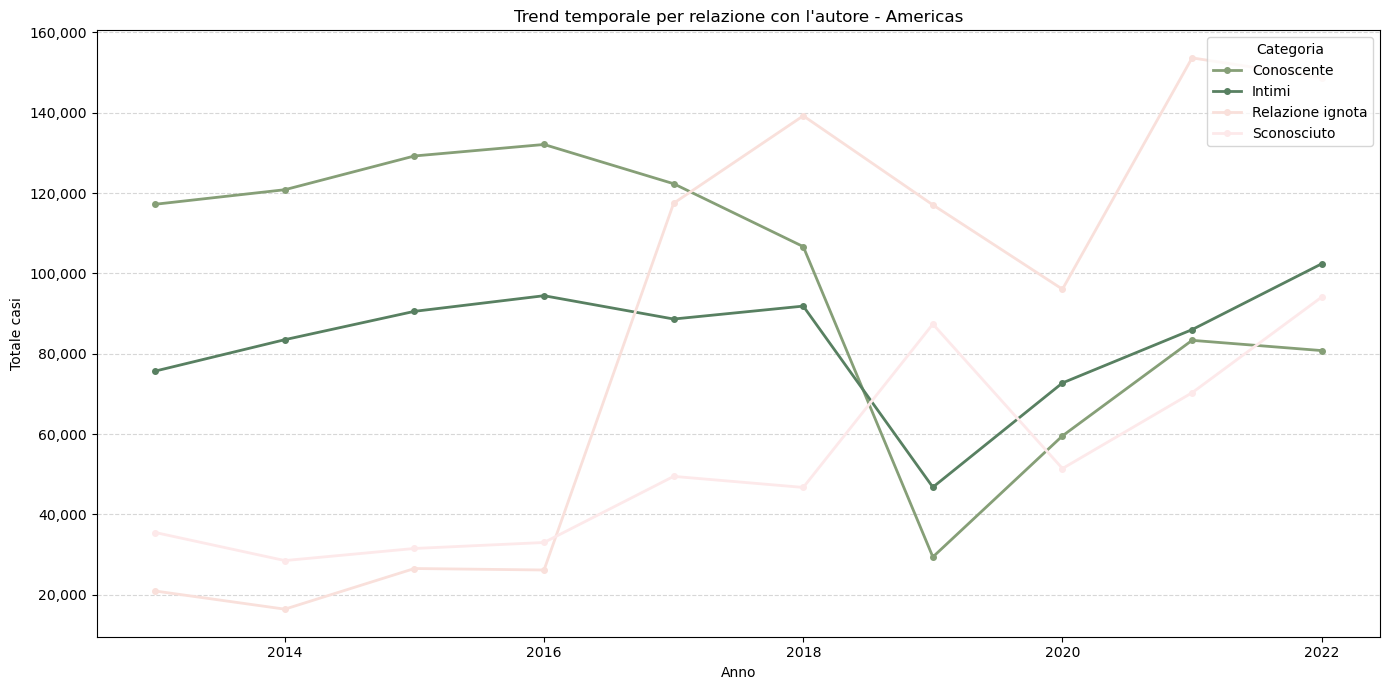

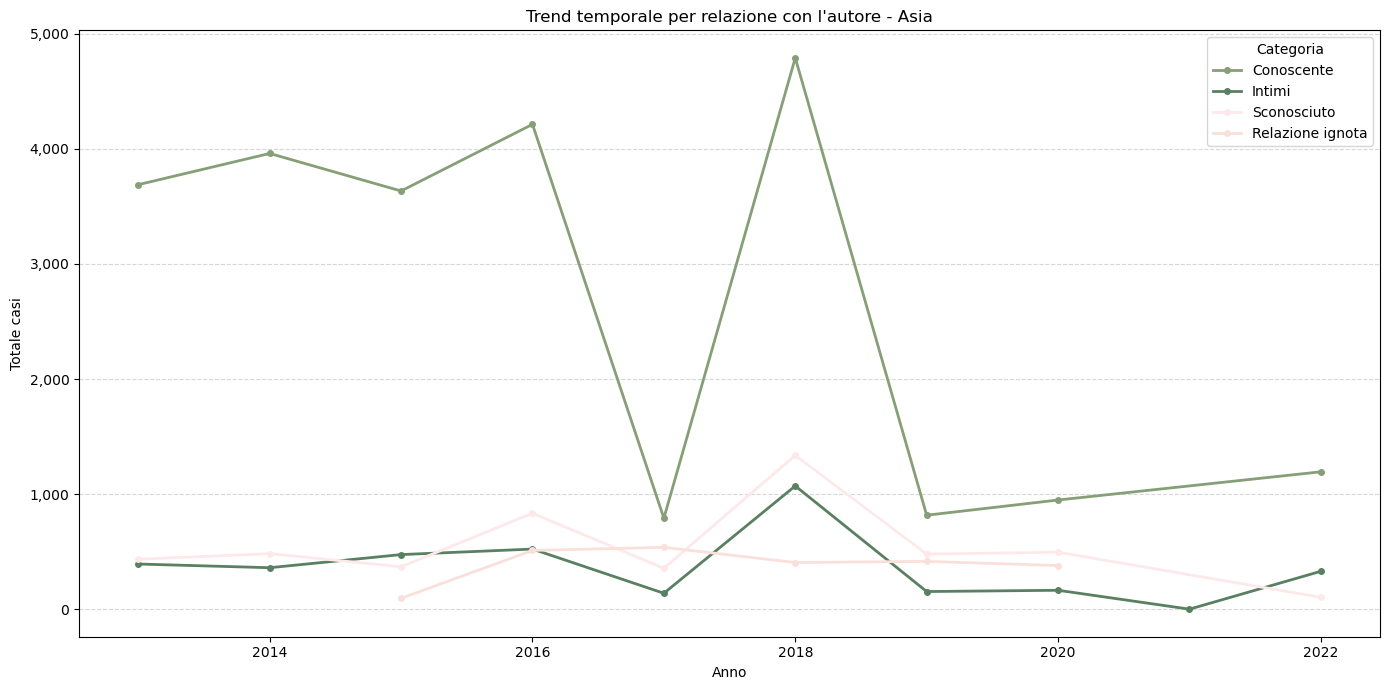

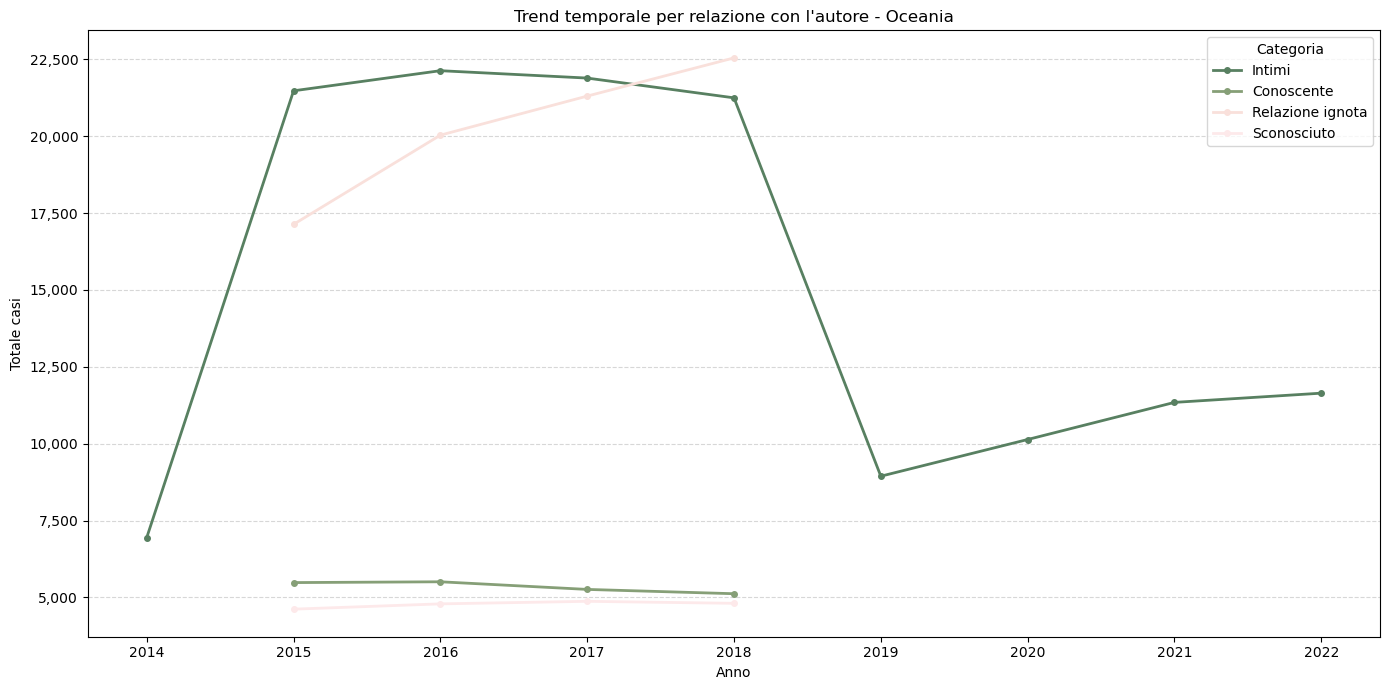

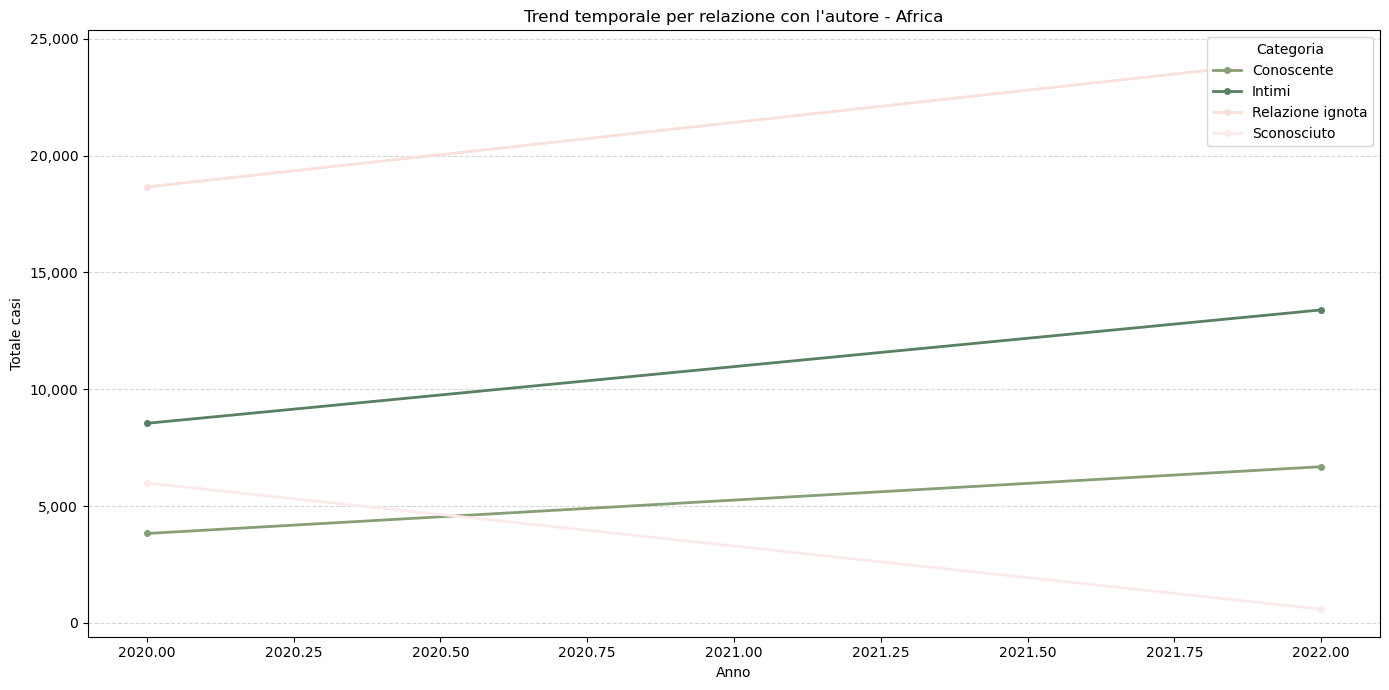

In [36]:
# filtro dimensione
relationship = data[data['Dimension'] == "by relationship to perpetrator"].copy()

# rinomino categorie
mappa_categorie = {
    'Intimate partner or family member': 'Intimi',
    'Other Perpetrator known to the victim': 'Conoscente',
    'Perpetrator unknown to the victim': 'Sconosciuto',
    'Relationship to perpetrator is not known': 'Relazione ignota'
}
relationship["Category"] = relationship["Category"].map(mappa_categorie)

# filtro solo i conteggi
relationship = relationship[relationship["Unit of measurement"] == "Counts"]

# colori
coloreReati = {
    "Intimi": "#588061",         
    "Conoscente": "#869F77",      
    "Sconosciuto": "#FDE9EA",     
    "Relazione ignota": "#F9E0DB" 
}

# ciclo per ogni regione
for regione in relationship["Region"].unique():
    
    dati_regione = relationship[relationship["Region"] == regione]
    
    trend = dati_regione.groupby(["Year", "Category"])["VALUE"].sum().reset_index()
    
    fig, ax = plt.subplots(figsize=(14, 7))
    
    for cat in trend["Category"].unique():
        dati = trend[trend["Category"] == cat]
        ax.plot(
            dati["Year"],
            dati["VALUE"],
            marker="o",
            linewidth=2,
            markersize=4,
            label=cat,
            color=coloreReati[cat]
        )
    
    ax.set_title(f"Trend temporale per relazione con l'autore - {regione}")
    ax.set_xlabel("Anno")
    ax.set_ylabel("Totale casi")
    
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    
    ax.legend(title="Categoria", loc="upper right")
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    
    plt.tight_layout()
    fig.savefig(f"trend_{regione}.png", dpi=300)  # <-- salva immagine
    plt.show()
    plt.close(fig)  # chiude il grafico per liberare memoria

In [37]:
data["Indicator"].unique()

array(['Violent offences', 'Victims of serious assault',
       'Victims of sexual violence'], dtype=object)

In [38]:
data["Year"].unique()

array([2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013,
       2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024])